## Desarrollo tarea HW Sesión 3

Felipe López Vergara

## 1. Regresión Simple
 
# ¿Cómo se relaciona la volatilidad con los retornos del mercado?

La volatilidad del mercado se puede medir a traves del indice VIX que refleja la expectativa de volatilidad del mercado a 30 días. Los retornos del mercado se pueden medir a traves del indice S&P 500 (ticker en yahoo finance ^GSPC). El VIX (ticker en yahoo finance ^VIX) es conocido como el índice del miedo porque cuando sube, los inversionistas esperan más incertidumbre o caídas en el mercado. Para responder la pregunta anterior, se puede realizar una regresión lineal simple entre la volatilidad del mercado y los retornos del mercado.


$\Delta VIX_t = \alpha + \beta \, r_{SP500,t} + \varepsilon_t$

Entender esta relacion es crucial para los inversionistas, ya que les permite anticipar movimientos del mercado y ajustar sus estrategias de inversión en consecuencia., por otro lado, ayuda a entender el comportamiento del mercado en periodos de stress.

Con la información anterior, debe hacer los siguientes pasos:

In [1]:
from matplotlib import pyplot as plt 
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd 
import seaborn as sns
import yfinance as yf
import numpy as np

sns.set_style("dark")

1.Considere al menos 10 años de historia (frecuencia mensual) de los índices VIX y S&P 500.

In [2]:
#Descarga precios del VIX y el S&P 500 desde Yahoo Finance.

vix = yf.download('^VIX', start = '2016-01-01', end = '2026-01-01', progress = False)['Close']
sp500 = yf.download('^GSPC', start = '2016-01-01', end = '2026-01-01', progress = False)['Close']

#Frecuencia mensual
vix_mensual = vix.resample('ME').last()
sp500_mensual = sp500.resample('ME').last()

df = pd.concat([sp500_mensual, vix_mensual], axis = 1)
df.columns = ['Ret_SP500', 'VIX']

df['r_SP500'] = df['Ret_SP500'].pct_change()*100
df['Delta_VIX'] = df['VIX'].diff()
df = df.dropna()

df.head()


,Ret_SP500,VIX,r_SP500,Delta_VIX
2016-02-29,1932.229980,20.549999,-0.412836,0.349998
2016-03-31,2059.739990,13.950000,6.599111,-6.599999
2016-04-30,2065.300049,15.700000,0.269940,1.750000
2016-05-31,2096.949951,14.190000,1.532460,-1.510000
2016-06-30,2098.860107,15.630000,0.091092,1.440001


2. Realice un scatterplot para visualizar la relación entre los dos índices e interprete lo que observa.

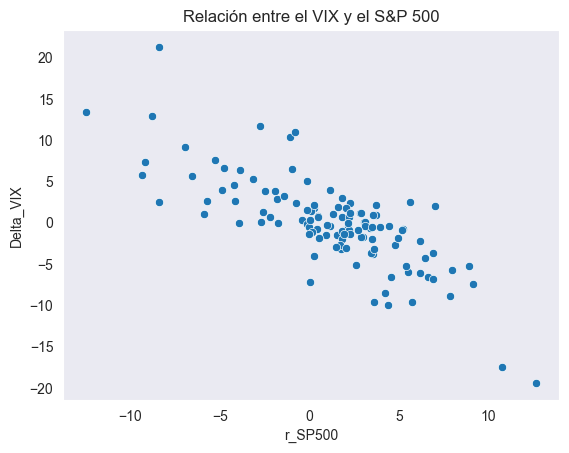

In [3]:
# Relación entre el VIX y el S&P 500

sns.scatterplot(x = 'r_SP500', y = 'Delta_VIX', data = df)
plt.title('Relación entre el VIX y el S&P 500')
plt.show()

Se puede desprender del gráfico que la relación del índice VIX que mide la expectativa de volatilidad esperada del índice S&P 500 a 30 dias y el retorno del S&P 500 es inversamente proporcional o tiene una correlación inversa, cuando aumenta el índice bursátil S&P 500 quiere decir que existe una tranquildad o estabilidad financiera y hay una baja en la volatilidad e incertidumbre del mercado por lo que el índice VIX disminuye. 

Se observa también que cuando el índice S&P 500 se encuentra en niveles bajos, el índice VIX presenta valores elevados y una mayor dispersión reflejando episodios de alta incertidumbre financiera.

2. Estime un modelo de regresión simple entre la volatilidad del mercado y los retornos del mercado

In [4]:
df.head()

,Ret_SP500,VIX,r_SP500,Delta_VIX
2016-02-29,1932.229980,20.549999,-0.412836,0.349998
2016-03-31,2059.739990,13.950000,6.599111,-6.599999
2016-04-30,2065.300049,15.700000,0.269940,1.750000
2016-05-31,2096.949951,14.190000,1.532460,-1.510000
2016-06-30,2098.860107,15.630000,0.091092,1.440001


In [5]:
# Implementacion manual de estimadores

xbar = df['r_SP500'].mean()
ybar = df['Delta_VIX'].mean()

beta_1 = np.sum((df['r_SP500']-xbar)*(df['Delta_VIX']-ybar)) / np.sum((df['r_SP500'] - xbar)**2)
beta_0 = ybar - beta_1*xbar 

print(f"(intercepto): {beta_0:.4f}")
print(f"(pendiente): {beta_1:.4f}")

(intercepto): 1.0884
(pendiente): -0.9771


In [6]:
#Modelo vía Statmodels

modelo = smf.ols(formula = 'Delta_VIX ~ r_SP500', data = df).fit()
modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Delta_VIX   R-squared:                       0.605
Model:                            OLS   Adj. R-squared:                  0.602
Method:                 Least Squares   F-statistic:                     179.4
Date:                Tue, 23 Jun 2026   Prob (F-statistic):           2.26e-25
Time:                        15:57:53   Log-Likelihood:                -314.83
No. Observations:                 119   AIC:                             633.7
Df Residuals:                     117   BIC:                             639.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.0884      0.326      3.335      0.001       0.442       1.735
r_SP500       -0.9771      0.073    -13.395      0.000      -1.122      -0.833
==============================================================================
Omnibus:                        6.956   Durbin-Watson:                   2.295
Prob(Omnibus):                  0.031   Jarque-Bera (JB):                9.888
Skew:                           0.250   Prob(JB):                      0.00712
Kurtosis:                       4.321   Cond. No.                         4.65
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Interprete los resultados del modelo de regresión en el contexto financiero.

Algunos datos del modelo muetra que tiene un coefciente de -0.9771 quiere decir que si el retorno mensual del S&P500 aumenta un 1% el índice VIX diminuye en 0.97 puntos, es decir, cuando las acciones suben, los inversionistas perciben menor riesgo reduciendo el VIX. También que el $R^2$ muetra que el retorno del S&P 500 explica aproximadamente el 60,5% la variabilidad del índice VIX. Al ser índices con relación inversa es consistente con el comprotamiento que en períodos de caídas bursátiles suelen estar asociados con aumentos en la incertidumbre y la volatilidad esperada del mercado (VIX).

5. Establezca una prueba de hipótesis para el parámetro de interés.

¿Explica índice S&P500 el precio de índice VIX ?

$H_0$ indica si el índicxe S&P500 no explica el precio del índice VIX y $H_1$ indica si el índicxe S&P500 tiene efecto sobre precio del índice VIX.

La prueba de Hipótesis es:

$H_0 : \beta = 0$

$H_1 : \beta \neq 0$

In [7]:
from scipy.stats import t

#Calculo del valor crítico t para un nivel de significancia del 5% 
df_resid = modelo.df_resid
alpha = 0.05 
t_critico = t.ppf(1-alpha/2, df = df_resid)

print(f"Valor crítico t : {t_critico:.4f}")

Valor crítico t : 1.9804


6. Ajuste el modelo de regresión y muestre los resultados visualmente.

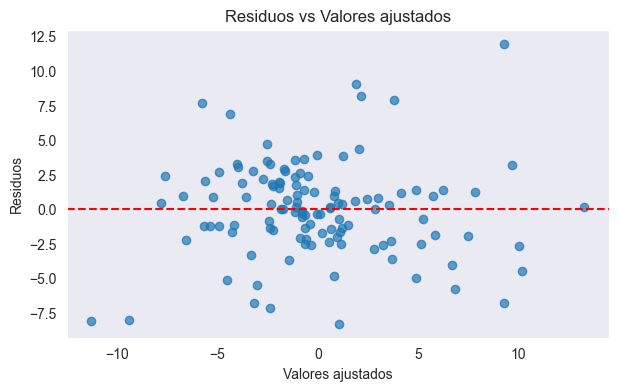

In [8]:
# Residuos vs Valores Ajustados

# Valores ajustados
Delta_VIX_ajustado = modelo.fittedvalues
# Residuos
residuos = modelo.resid

plt.figure(figsize = (7,4))
plt.scatter(Delta_VIX_ajustado, residuos, alpha = 0.7)
plt.axhline(0, color = 'red', linestyle = '--')
plt.xlabel('Valores ajustados')
plt.ylabel('Residuos')
plt.title('Residuos vs Valores ajustados')
plt.show()


Se rechaza la hipótesis nula para un nivel de significancia si el verdadero valor del estadístico t cumple:

$$|t| > t_{n-k-1,\alpha/2}$$

$$|t_{\beta_1}| = |-13.395| = 13.395 > t_c = 1.9804$$

En este caso, el valor del estadístico de prueba t -13.395 en valor absoluto es mayor al valor crítico t de 1.9804. Por lo tanto, se rechaza la hipótesis $H_0$ y existe la evidencia estadística que el $\beta_1$ es distinto de cero por lo que la variable del índice S&P500 tiene un efecto significativo sobre el índice VIX.


In [9]:
# Contraste de prueba de hipótesis mediante p_value

t_obs = -13.395 # t-ratio de beta_1 
df2 = df_resid

# p-valor bilateral
p_value = 2 * t.sf(abs(t_obs), df2)
print(f"p-valor (bilateral): {p_value:.4e}")

p-valor (bilateral): 2.2665e-25


Se rechaza la hipótesis nula al 5% de significancia ya que el p_value es mucho menor que 0.05 entonces hay evidencia muy fuerte de que $\beta_1$ es distinto de cero.

7.¿Qué tanto explica el SP500?

 El $R^2$ indica que el el modelo presenta un coeficiente de determinación de 0.605, es decir, que las variaciones del retorno del S&P 500 explican aproximadamente el 60,5 % de la variabilidad del VIX. El otro 39,5% se puede atribuir a factores externos al modelo como expectativas de los inversionistas, datos macroeconómicos, eventos geopolíticos o decisiones de política monetaria.

## 2. Regresión Multiple

Extendamos la versión anterior del modelo a una version más completa que considere otros factores que pueden influir en la volatilidad del mercado. Incluya en el modelo las siguientes variables:

Retorno absoluto del S&P 500: Captura el efecto de grandes movimientos, sean positivos o negativos, sobre la volatilidad. Ejemplo de cómo calcularlo: abs(r_SP500)

Retorno rezagado del S&P 500: La volatilidad puede responder con rezago a movimientos del mercado. Ejemplo de cómo calcularlo: r_SP500.shift(1)

Cambio en volumen del S&P 500: Un aumento en el volumen suele asociarse a mayor incertidumbre. Ejemplo de cómo calcularlo: volume_SP500.pct_change()

Cambio en VIX del día anterior: La volatilidad suele mostrar persistencia temporal. ejemplo de cómo calcularlo: VIX.shift(1)

Con esta información, debe hacer los siguientes pasos:

1. Genere un analisis de correlacion entre las variables y comente los resultados.

In [10]:
#Agregar variables

# Retorno absoluto
df['abs_r_SP500'] = df['r_SP500'].abs()

# Retorno rezagado
df['r_SP500_rezagado'] = df['r_SP500'].shift(1)

# Cambio de volumen
sp500_volume = yf.download('^GSPC', start = '2016-01-01', end = '2026-01-01', progress = False).resample('ME').last()[['Volume']]
df['Volume_SP500'] = sp500_volume['Volume']
df['vol_change'] = df['Volume_SP500'].pct_change()

# Cambio del VIX rezagado
df['VIX_rezagado'] = df['VIX'].shift(1)

# Variable dependiente
df['Delta_VIX'] = df['VIX'].diff()

df = df.dropna()
# Data final
df_corr = df[['Delta_VIX','r_SP500','abs_r_SP500',
              'r_SP500_rezagado','vol_change','VIX_rezagado']].dropna()

df_corr.corr()

,Delta_VIX,r_SP500,abs_r_SP500,r_SP500_rezagado,vol_change,VIX_rezagado
Delta_VIX,1.000000,-0.778245,-0.111780,0.290371,0.220054,-0.389722
r_SP500,-0.778245,1.000000,0.059394,-0.148078,-0.023646,0.176275
abs_r_SP500,-0.111780,0.059394,1.000000,-0.343811,0.018456,0.564356
r_SP500_rezagado,0.290371,-0.148078,-0.343811,1.000000,-0.091583,-0.433789
vol_change,0.220054,-0.023646,0.018456,-0.091583,1.000000,-0.065702
VIX_rezagado,-0.389722,0.176275,0.564356,-0.433789,-0.065702,1.000000


La matriz de correlación muestra que la variación del VIX presenta una relación positiva más fuerte con su propio rezago, lo que sugiere alta persistencia temporal de la volatilidad. Asimismo, el retorno absoluto del S&P 500 exhibe una correlación positiva con la volatilidad, consistente con el efecto de grandes movimientos de mercado sobre la incertidumbre. El cambio en volumen transado presenta una correlación positiva más débil, indicando que la actividad de mercado contribuye parcialmente a la volatilidad, aunque con mayor ruido. Finalmente, el retorno rezagado del S&P 500 muestra una relación más limitada, lo que sugiere que los efectos de corto plazo de los retornos sobre la volatilidad son menos persistentes.

2.Estime el modelo de regresión múltiple con las variables mencionadas.

In [29]:
# Variables explicativas
X = df[[
    "abs_r_SP500",
    "r_SP500_rezagado",
    "vol_change",
    "VIX_rezagado"
]]

# Variable dependiente
y = df["Delta_VIX"]


# Agregar constante
X = sm.add_constant(X)

# Estimar modelo OLS
model_reg_mult = sm.OLS(y, X).fit()
# Estimar modelo OLS
#model_reg_mult = smf.ols(formula = 'Delta_VIX ~ r_SP500 + VIX + vol_change + VIX_rezagado', data = df).fit()
# Resultados
print(model_reg_mult.summary())

                            OLS Regression Results                            
Dep. Variable:              Delta_VIX   R-squared:                       0.236
Model:                            OLS   Adj. R-squared:                  0.209
Method:                 Least Squares   F-statistic:                     8.709
Date:                Tue, 23 Jun 2026   Prob (F-statistic):           3.65e-06
Time:                        16:54:00   Log-Likelihood:                -351.68
No. Observations:                 118   AIC:                             713.4
Df Residuals:                     113   BIC:                             727.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                3.8615      1.475  

Establezca una prueba de hipótesis para los parámetros de interés.

In [30]:
df_resid = model_reg_mult.df_resid # n-k (en k contiene ya el 1 por el intercepto)

alpha = 0.05
t_critico = t.ppf(1-alpha/2, df = df_resid)

print(f"Valor crítico t : {t_critico:.4f}")

Valor crítico t : 1.9812


**(a) Retorno absoluto del S&P 500**
La prueba consite en demostrar si los cambios grandes en el S&P 500 influyen en el comportamiento del VIX.

$H_0 : \beta_1 = 0$

$H_1 : \beta_1 \neq 0$

$$t = \frac{\hat{\beta}_1}{SE({\beta}_1)}
= \frac{0.3372}{0.199}
= 1.697$$

Se rechaza la hipótesis nula para un nivel de significancia si el verdadero valor del estadístico t cumple:

$$|t| > t_{n-k-1,\alpha/2}$$

$$|t_{\beta_1}| = |1.697| = 1.697 > t_c = 1.9812$$

No se rechaza $H_0$. No existe evidencia estadística suficiente al 5% para afirmar que los movimientos absolutos del S&P 500 afectan el cambio del VIX. Pero al 10% (Valor crítico t : 1.6585) muestra que existe una evidencia débil.

**(b) Retorno rezagado del S&P 500**
 $H_0$ indica si el retorno rezagado del S&P 500 no explica el precio de VIX, mientras que $H_1$ si el retorno rezagado del S&P 500 explica el precio de VIX. La prueba de hipóstesis a cointrastar es:

$H_0 : \beta_2 = 0$

$H_1 : \beta_2 \neq 0$

$$t = \frac{\hat{\beta}_2}{SE({\beta}_2)}
= \frac{0.2529}{0.117}
= 2.169$$

Se rechaza la hipótesis nula para un nivel de significancia si el verdadero valor del estadístico t cumple:

$$|t| > t_{n-k-1,\alpha/2}$$

$$|t_{\beta_2}| = |2.169| = 2.169 > t_c = 1.9812$$
$$t = \frac{\hat{\beta}_2}{SE({\beta}_2)}
= \frac{3.6098}{1.431}
= 2.522$$

Se rechaza $H_0$. existe evidencia estadística significativa de que el coeficiente $\beta_2$ es distinto de 0, es decir, el retorno pasado del mercado tiene un efecto significativo sobre el cambio del índice VIX.

**(c) Cambio en el volumen**
 $H_0$ indica si el cambio en el volumen del S&P 500 no explica el precio de VIX, mientras que $H_1$ si el cambio en el volumen del S&P 500 explica el precio de VIX. La prueba de hipóstesis a cointrastar es:

$H_0 : \beta_3 = 0$

$H_1 : \beta_3 \neq 0$

$$t = \frac{\hat{\beta}_3}{SE({\beta}_3)}
= \frac{3.6098}{1.431}
= 2.522$$

Se rechaza la hipótesis nula para un nivel de significancia si el verdadero valor del estadístico t cumple:

$$|t| > t_{n-k-1,\alpha/2}$$

$$|t_{\beta_3}| = |2.522| = 2.522 > t_c = 1.9812$$

Se rechaza $H_0$. existe evidencia estadística significativa de que el coeficiente $\beta_3$ es distinto de 0, es decir, el cambio en el volumen del S&P 500 tiene un efecto significativo sobre el cambio del índice VIX.

**(d) VIX rezagado**
 $H_0$ indica si el cambio en VIX del día anterior no explica el precio de VIX, mientras que $H_1$ si el cambio en VIX del día anterior explica el precio de VIX. La prueba de hipóstesis a cointrastar es:

$H_0 : \beta_4 = 0$

$H_1 : \beta_4 \neq 0$

$$t = \frac{\hat{\beta}_4}{SE({\beta}_4)}
= \frac{-0.3008}{0.083}
= 3.645$$

Se rechaza la hipótesis nula para un nivel de significancia si el verdadero valor del estadístico t cumple:

$$|t| > t_{n-k-1,\alpha/2}$$

$$|t_{\beta_4}| = |-3.645| = 3.645 > t_c = 1.9812$$

Se rechaza $H_0$. existe evidencia estadística significativa de que el coeficiente $\beta_4$ es distinto de 0, es decir, el cambio en VIX del día anterior tiene un efecto significativo sobre el cambio del índice VIX.

5.Establezca una prueba de hipotesis para el modelo completo.

$H_0 : \beta_1 = \beta_2 = \beta_3 = \beta_4 = 0$

$H_1 : al menos uno de los \beta_i \neq 0$

El estadístico de contraste es:

$$F = \frac{R^2 / k}{(1 - R^2) / (n - k - 1)}$$

Se rechaza $H_0$ si $F > F_{K;n-k-1} con un nivel de significancia $\alpha$ o, equivalentemente, si el $p-value$ asociado al estadístico $F$ es menor que $\alpha$, es decir, $p-value$ < $\alpha$, se rechaza la hipótesis nula.

In [13]:
R2 = model_reg_mult.rsquared
print(f"R2: {R2:.6f}")

R2: 0.235629


In [14]:
n = X.shape[0]           
k = X.shape[1] - 1       
F_manual = (R2 / k) / ((1 - R2) / (n - k - 1))
print("Estadístico F (manual):", F_manual)
print("Estadístico F (statsmodels):", model_reg_mult.fvalue)

Estadístico F (manual): 8.708511482968373
Estadístico F (statsmodels): 8.708511482968373


In [15]:
# p-value del test F del modelo ols
model_reg_mult.f_pvalue

np.float64(3.6509628297873044e-06)

In [16]:
# Estadistico F del modelo ols 
model_reg_mult.fvalue

np.float64(8.708511482968373)

In [17]:
from scipy.stats import f
alpha = 0.05
f_critico = f.ppf(1-alpha, k, n - k - 1)
print(f"F crítico al {100*(1-alpha)}% de confianza: {f_critico:.4f}")

F crítico al 95.0% de confianza: 2.4520


Por tanto, dado que $F_obs > F_critico$, se rechaza la hipótesis nula, es decir existe evidencia estadística significativa en donde al menos una variable explicativa está relacionada con la variable respuesta.

6.¿ Hay evidencia de multicolinealidad?, comente.

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df[['abs_r_SP500',
        'r_SP500_rezagado',
        'vol_change',
        'VIX_rezagado']]

vif = pd.DataFrame()
vif["Variable"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i)
              for i in range(X_vif.shape[1])]

print(vif)

           Variable       VIF
0       abs_r_SP500  3.961932
1  r_SP500_rezagado  1.038721
2        vol_change  1.019220
3      VIX_rezagado  3.991212


En este caso, todos los VIF están por debajo de 4, por lo que no se observa multicolinealidad importante, las variables abs_r_SP500 y VIX_rezagado presentan una cierta correlación moderada entre predictores, pero no es suficiente para comprometer la estabilidad del modelo.

7. Este modelo, ¿cumple los supuestos de Gauss-Markov?, comente.

**Verificación de supuesto de linealidad y homocedasticidad**

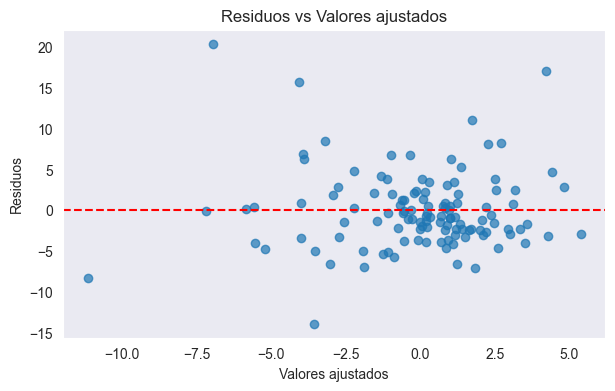

In [19]:
# Residuos vs Valores Ajustados
fitted_vals_reg_mul = model_reg_mult.fittedvalues
residuals_reg_mul = model_reg_mult.resid

plt.figure(figsize = (7,4))
plt.scatter(fitted_vals_reg_mul, residuals_reg_mul, alpha = 0.7)
plt.axhline(0, color = 'red', linestyle = '--')
plt.xlabel('Valores ajustados')
plt.ylabel('Residuos')
plt.title('Residuos vs Valores ajustados')
plt.show()

Los residuos están dispersos aleatoriamente alrededor de cero, sin patrones claros ni forma de embudo, es decir, hay linealidad o heterocedasticidad en los rediduos.

**Verificación de supuesto de normalidad**

<Figure size 700x400 with 0 Axes>

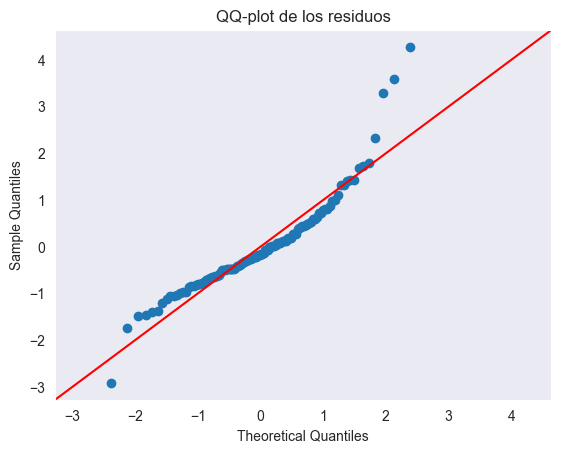

In [20]:
# Normalidad de los residuos
plt.figure(figsize = (7,4))
sm.qqplot(residuals_reg_mul, line = '45', fit = True)
plt.title('QQ-plot de los residuos')
plt.show()

Los puntos están alineados con la línea diagonal. por lo tanto no tiene desviaciones importantes que indiquen que los residuos no son normales.

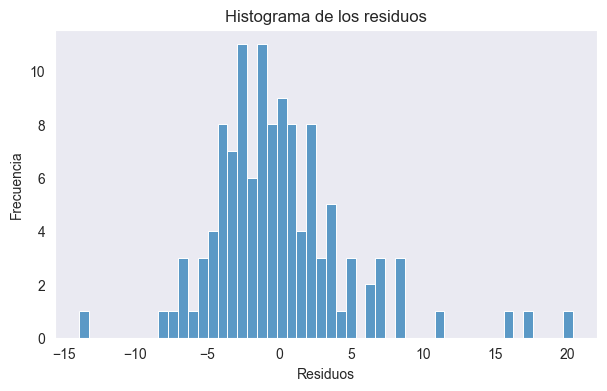

In [21]:
plt.figure(figsize=(7,4))
sns.histplot(residuals_reg_mul, bins = 50, alpha = 0.7 )
plt.title('Histograma de los residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.show()

El histograma parecerse a una campana (distribución normal).

Estime el modelo mediante máxima verosimilitud y compare los resultados con el modelo de mínimos cuadrados ordinarios (OLS).

In [34]:

from scipy.optimize import minimize

X = sm.add_constant(df[[
    "abs_r_SP500",
    "r_SP500_rezagado",
    "vol_change",
    "VIX_rezagado"
]])

y = df["Delta_VIX"].values

def log_likelihood(params):
    beta = params[:-1]
    sigma = params[-1]
    
    y_hat = X.values @ beta
    residuals = y - y_hat
    
    n = len(y)
    
    ll = - (n/2)*np.log(2*np.pi*sigma**2) - (1/(2*sigma**2))*np.sum(residuals**2)
    return -ll  # minimizamos el negativo

# parámetros iniciales
init = np.append(np.zeros(X.shape[1]), 1)

result = minimize(log_likelihood, init)

beta_mv = result.x[:-1]
sigma_mv = result.x[-1]

print("Coeficientes MV:", beta_mv)
print("Sigma MV:", sigma_mv)

# Comparación con statsmodels
comparacion = pd.DataFrame({
    "Statsmodels OLS": model_reg_mult.params,
    "Máxima verosimilitud": beta_mv
})

print(comparacion)


Coeficientes MV: [ 3.86151992  0.33715578  0.2529276   3.60978229 -0.30079753]
Sigma MV: 4.765455498709751
                  Statsmodels OLS  Máxima verosimilitud
const                    3.861517              3.861520
abs_r_SP500              0.337155              0.337156
r_SP500_rezagado         0.252928              0.252928
vol_change               3.609784              3.609782
VIX_rezagado            -0.300797             -0.300798


Concluya con un breve resumen de los hallazgos y su relevancia para la toma de decisiones financieras.

Los resultados muestran que las estimaciones por Máxima Verosimilitud y Mínimos Cuadrados Ordinarios son prácticamente iguales en todos los coeficientes, se puede concluir que la volatilidad de mercado (índice VIX) está principalmente impulsado por los movimeintos bruscos del mercado y aumento en los volumenen, ya que hay mayaor transacciones e información nueva lo que lleva a un mayor nivel de incertidumbre.